# Étape 2 : Prétraitement & Feature Engineering

## Objectif
Préparer les données pour la modélisation en effectuant trois actions :

1. **Normalisation** : mettre Amount et Time à la même échelle que les 
   features V1-V28 (déjà normalisées par la PCA). Un modèle qui reçoit 
   des features sur des échelles très différentes (Amount va de 0 à 25 000, 
   V1 tourne autour de 0) donnera trop d'importance aux grandes valeurs.

2. **Feature Engineering** : créer de nouvelles features pertinentes à 
   partir de Time et Amount pour améliorer le pouvoir prédictif du modèle.

3. **Préparation du jeu de données** : séparer les features (X) de la 
   cible (y) et créer les jeux train/test.

## 2.1 — Normalisation de Amount et Time
Les features V1-V28 sont déjà normalisées par la PCA. Amount (0 à 25 691) et 
Time (0 à 172 792) sont sur des échelles très différentes. On les normalise 
avec StandardScaler pour que chaque feature ait une moyenne de 0 et un écart-type de 1.

=== VÉRIFICATION DE LA NORMALISATION ===
Amount → moyenne: -0.0000, écart-type: 1.0000
Time → moyenne: -0.0000, écart-type: 1.0000


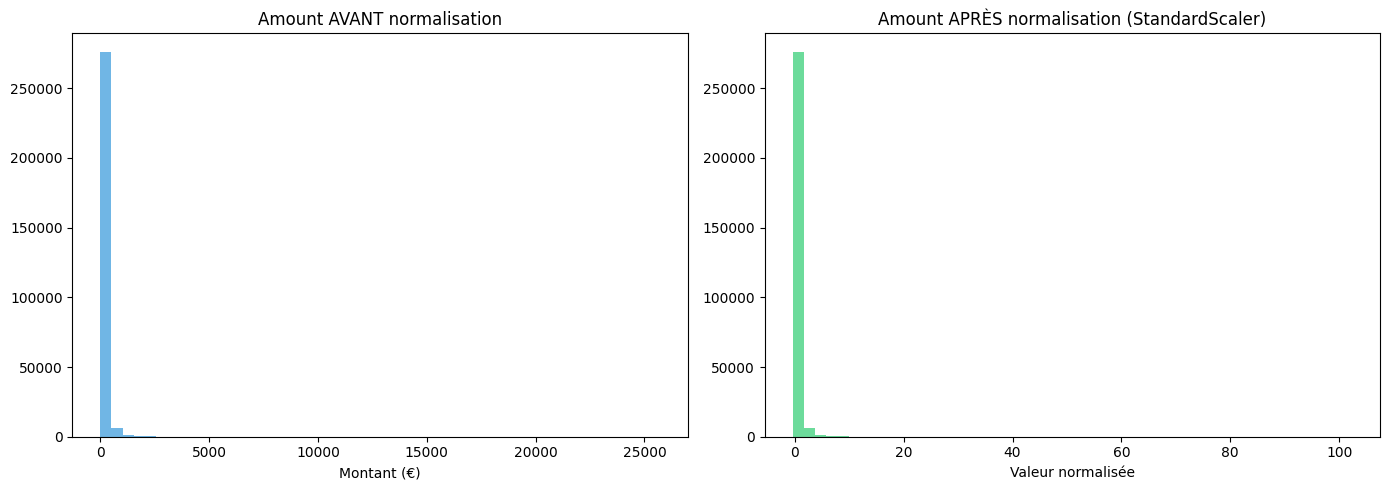

In [1]:
# ============================================
# 2.1 — Imports et normalisation
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Chargement
df = pd.read_csv('../data/creditcard.csv')

# Sauvegarde des colonnes originales avant transformation
df['Amount_original'] = df['Amount']
df['Time_original'] = df['Time']

# Normalisation de Amount et Time
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

# Vérification : les features normalisées doivent avoir mean ≈ 0 et std ≈ 1
print("=== VÉRIFICATION DE LA NORMALISATION ===")
for col in ['Amount', 'Time']:
    print(f"{col} → moyenne: {df[col].mean():.4f}, écart-type: {df[col].std():.4f}")

# Comparaison visuelle avant/après
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount_original'], bins=50, color='#3498db', alpha=0.7)
axes[0].set_title('Amount AVANT normalisation')
axes[0].set_xlabel('Montant (€)')

axes[1].hist(df['Amount'], bins=50, color='#2ecc71', alpha=0.7)
axes[1].set_title('Amount APRÈS normalisation (StandardScaler)')
axes[1].set_xlabel('Valeur normalisée')

plt.tight_layout()
plt.savefig('../outputs/normalisation_amount.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 — Feature Engineering
On crée de nouvelles features à partir de Time et Amount pour donner 
au modèle des informations supplémentaires qu'il ne pourrait pas 
déduire facilement des données brutes.

=== NOUVELLES FEATURES CRÉÉES ===
Hour : min=0.0, max=24.0

Is_Night : distribution →
Is_Night
0    249934
1     34873
Name: count, dtype: int64

Amount_log : min=0.00, max=10.15

Amount_category : distribution →
Amount_category
0    100264
1     90781
2     64925
3     25897
4      2940
Name: count, dtype: int64


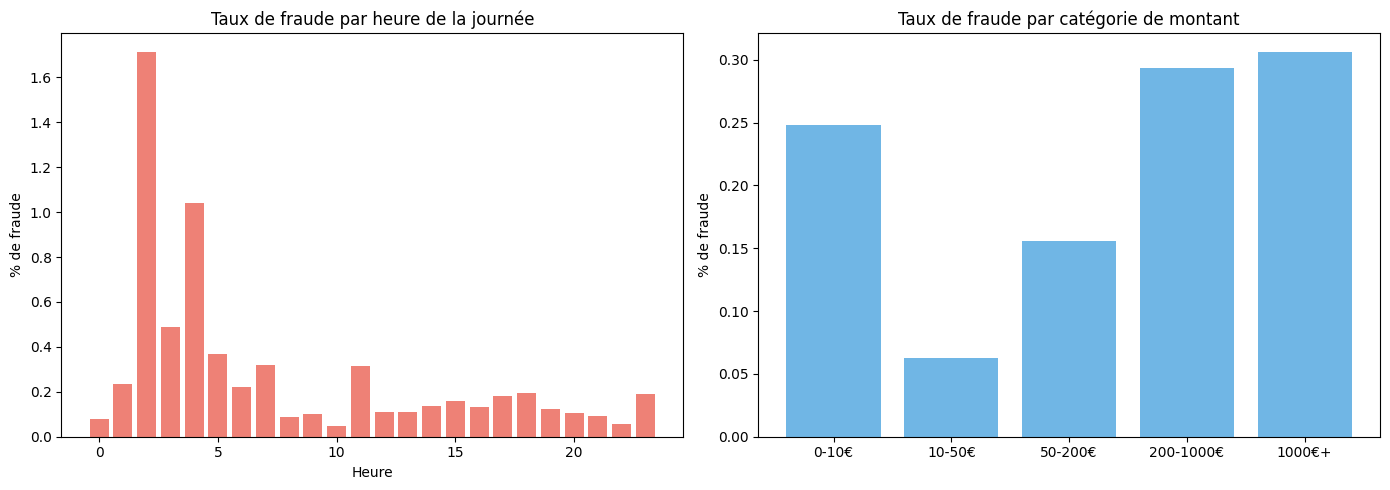

In [2]:
# ============================================
# 2.2 — Feature Engineering
# ============================================

# 1. Extraire l'heure de la journée à partir de Time
# Time = secondes depuis la 1ère transaction, sur ~48h
# On utilise modulo 86400 (= 24h en secondes) pour avoir l'heure cyclique
df['Hour'] = (df['Time_original'] % 86400) / 3600  # Heure de 0 à 24

# 2. Indicateur de transaction nocturne (entre 23h et 6h)
df['Is_Night'] = ((df['Hour'] >= 23) | (df['Hour'] <= 6)).astype(int)

# 3. Log du montant (réduit l'effet des valeurs extrêmes)
df['Amount_log'] = np.log1p(df['Amount_original'])

# 4. Catégorie de montant
df['Amount_category'] = pd.cut(
    df['Amount_original'],
    bins=[0, 10, 50, 200, 1000, 30000],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True
).astype(int)

# Vérification
print("=== NOUVELLES FEATURES CRÉÉES ===")
print(f"Hour : min={df['Hour'].min():.1f}, max={df['Hour'].max():.1f}")
print(f"\nIs_Night : distribution →\n{df['Is_Night'].value_counts()}")
print(f"\nAmount_log : min={df['Amount_log'].min():.2f}, max={df['Amount_log'].max():.2f}")
print(f"\nAmount_category : distribution →\n{df['Amount_category'].value_counts().sort_index()}")

# Visualisation : taux de fraude par tranche horaire
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraudes par heure
hourly_fraud = df.groupby(df['Hour'].astype(int))['Class'].mean() * 100
axes[0].bar(hourly_fraud.index, hourly_fraud.values, color='#e74c3c', alpha=0.7)
axes[0].set_title('Taux de fraude par heure de la journée')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('% de fraude')

# Fraudes par catégorie de montant
cat_fraud = df.groupby('Amount_category')['Class'].mean() * 100
cat_labels = ['0-10€', '10-50€', '50-200€', '200-1000€', '1000€+']
axes[1].bar(cat_labels, cat_fraud.values, color='#3498db', alpha=0.7)
axes[1].set_title('Taux de fraude par catégorie de montant')
axes[1].set_ylabel('% de fraude')

plt.tight_layout()
plt.savefig('../outputs/feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Engineering — Justification des choix

**Heure de la journée** : Time était exprimé en secondes écoulées depuis la 
première transaction — inexploitable tel quel. On le transforme en heure (0-24) 
car le comportement transactionnel suit un cycle jour/nuit. L'heure est le bon 
niveau de granularité : par minute serait trop fin (pas assez de données par bin), 
et le dataset ne couvre que 48h, ce qui exclut une analyse par jour de la semaine 
ou par mois.

**Catégories de montant** : les seuils choisis (10, 50, 200, 1000€) sont une 
hypothèse métier visant à séparer petits achats, achats moyens et gros montants. 
Ce choix est arbitraire et devra être validé par les performances du modèle — 
si la feature n'apporte rien, on la retirera.

## 2.3 — Séparation features/cible et split train/test
On sépare les données en jeu d'entraînement (80%) et de test (20%). 
Le jeu de test ne sera JAMAIS touché pendant l'entraînement — il simule 
des transactions futures que le modèle n'a jamais vues.

In [ ]:
# ============================================
# 2.3 — Préparation train/test
# ============================================
from sklearn.model_selection import train_test_split

# Colonnes à supprimer (originaux gardés uniquement pour référence)
cols_to_drop = ['Class', 'Amount_original', 'Time_original']

# Séparation features (X) et cible (y)
X = df.drop(columns=cols_to_drop)
y = df['Class']

print(f"Features (X) : {X.shape}")
print(f"Cible (y) : {y.shape}")
print(f"\nColonnes utilisées ({X.shape[1]}) :")
print(list(X.columns))

# Split train/test stratifié
# stratify=y garantit que le ratio fraude/légitime est le même dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n=== SPLIT TRAIN/TEST ===")
print(f"Train : {X_train.shape[0]} transactions")
print(f"Test  : {X_test.shape[0]} transactions")
print(f"\nFraudes dans train : {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraudes dans test  : {y_test.sum()} ({y_test.mean()*100:.3f}%)")

# Sauvegarde pour les notebooks suivants
import pickletaux
data_dict = {
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test
}
with open('../outputs/preprocessed_data.pkl', 'w+b') as f:
    pickle.dump(data_dict, f)

print("\nDonnées sauvegardées dans outputs/preprocessed_data.pkl")

Features (X) : (284807, 34)
Cible (y) : (284807,)

Colonnes utilisées (34) :
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'Is_Night', 'Amount_log', 'Amount_category']

=== SPLIT TRAIN/TEST ===
Train : 227845 transactions
Test  : 56962 transactions

Fraudes dans train : 394 (0.173%)
Fraudes dans test  : 98 (0.172%)

Données sauvegardées dans outputs/preprocessed_data.pkl


## Conclusion — Étape 2

Nous avons préparé les données pour la modélisation :

**Normalisation** : Amount et Time ont été mis à la même échelle que les 
features V1-V28 via StandardScaler (moyenne = 0, écart-type = 1).

**Feature Engineering** : 4 nouvelles features ont été créées :
- `Hour` : heure de la journée (extraite de Time), validée par le pic de 
  fraude observé entre 2h et 4h du matin.
- `Is_Night` : indicateur binaire nuit/jour (23h-6h).
- `Amount_log` : log du montant, pour réduire l'effet des valeurs extrêmes.
- `Amount_category` : catégorie de montant (choix arbitraire à valider par 
  les performances du modèle).

**Split train/test** : séparation 80/20 avec stratification pour conserver 
le même ratio de fraude (~0.17%) dans les deux jeux. Les données ont été 
sauvegardées en pickle pour les étapes suivantes.